# 🟢 GraphSAGE Pipeline — Train on FakeNews & Predict on WelFake

**Graph Sample and Aggregate (GraphSAGE)** — kiến trúc GNN không dùng cơ chế attention như GAT, thay vào đó dùng **sampling + aggregation** để học biểu diễn node.

---

## GCN vs GAT vs GraphSAGE — Sự khác biệt cốt lõi

| | GCN | GAT | GraphSAGE |
|---|---|---|---|
| **Aggregation** | Trung bình có trọng số cố định (degree-based) | Trung bình có trọng số **học được** (attention) | **Sample** neighbors rồi aggregate (mean/max/LSTM) |
| **Neighbors** | Tất cả neighbors **bằng nhau** | Mỗi neighbor có **trọng số khác nhau** | **Sample ngẫu nhiên** một tập con neighbors |
| **Multi-head** | ❌ | ✅ (nhiều head = nhiều góc nhìn) | ❌ |
| **Inductive** | ❌ Transductive | ✅ **Inductive** hơn | ✅ **Fully Inductive** |
| **Scalability** | Trung bình | Trung bình | **Tốt** — mini-batch friendly |

### Công thức GraphSAGE:

$$h_{\mathcal{N}(v)}^{(k)} = \text{AGGREGATE}_k\left(\{h_u^{(k-1)}, \forall u \in \mathcal{N}(v)\}\right)$$

$$h_v^{(k)} = \sigma\left(W^k \cdot \text{CONCAT}\left(h_v^{(k-1)}, h_{\mathcal{N}(v)}^{(k)}\right)\right)$$

---

## Tổng quan pipeline

```
true.csv + fake.csv
       │
       ▼
 [1] Load & Preprocess Text
       │
       ▼
 [2] TF-IDF Feature Extraction  (2000 features)
       │
       ▼
 [3] KNN Graph Construction     (k=5)
       │
       ▼
 [4] GraphSAGE Model Training   (2-layer SAGEConv, 150 epochs)
       │
       ▼
 [5] Evaluation + GCN/GAT Comparison (intra-dataset)
       │
       ▼
 [6] Save Checkpoint
       │
       ▼
 [7] Cross-dataset Prediction on WelFake
       │
       ▼
 [8] Full Comparison Table
```

---
## ⚙️ Cell 0 — Import thư viện & Cấu hình

In [1]:
import sys
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import csr_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import SAGEConv, GCNConv, GATConv
from torch_geometric.data import Data

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {DEVICE}")

PyTorch version : 2.8.0
CUDA available  : False
Device          : cpu


In [2]:
# ── Tự động tìm PROJECT_ROOT ─────────────────────────────────────────────────
cwd = Path('.').resolve()
PROJECT_ROOT = cwd
for _ in range(4):
    if (PROJECT_ROOT / 'data').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR        = PROJECT_ROOT / 'data' / 'raw'
CKPT_DIR       = PROJECT_ROOT / 'output' / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_SAGE = CKPT_DIR / 'sage_fakenews.pt'
CHECKPOINT_GCN  = CKPT_DIR / 'gcn_fakenews.pt'
CHECKPOINT_GAT  = CKPT_DIR / 'gat_fakenews.pt'
WELFAKE_PATH    = RAW_DIR  / 'WELFake_Dataset.csv'

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"fake.csv       : {(RAW_DIR/'fake.csv').exists()}")
print(f"true.csv       : {(RAW_DIR/'true.csv').exists()}")
print(f"WelFake CSV    : {WELFAKE_PATH.exists()}")
print(f"GCN checkpoint : {CHECKPOINT_GCN.exists()} ← dùng để so sánh")
print(f"GAT checkpoint : {CHECKPOINT_GAT.exists()} ← dùng để so sánh")

PROJECT_ROOT   : /Users/macbook/Documents/HK2_Nam3(2526)/Theory/Graph Mining/Fake-News-Detection-GNN
fake.csv       : True
true.csv       : True
WelFake CSV    : True
GCN checkpoint : True ← dùng để so sánh
GAT checkpoint : True ← dùng để so sánh


In [3]:
# ── Hyperparameters ─────────────────────────────────────────────────────────
# Data
SAMPLE_SIZE   = -1   # Số article FakeNews (-1 = all)
MAX_FEATURES  = 2000   # TF-IDF features
KNN_K         = 5      # KNN neighbors
TEST_RATIO    = 0.3
RANDOM_SEED   = 42
WELFAKE_SAMPLE = 3000  # Số article WelFake dùng cross-dataset

# GraphSAGE Architecture
SAGE_HIDDEN   = 256    # Hidden dim
SAGE_DROPOUT  = 0.5    # Dropout rate

# Training
EPOCHS        = 150
LEARNING_RATE = 5e-4
WEIGHT_DECAY  = 5e-4

print("GraphSAGE Hyperparameters:")
print(f"  SAMPLE_SIZE    = {SAMPLE_SIZE}")
print(f"  MAX_FEATURES   = {MAX_FEATURES}")
print(f"  KNN_K          = {KNN_K}")
print(f"  SAGE_HIDDEN    = {SAGE_HIDDEN}")
print(f"  SAGE_DROPOUT   = {SAGE_DROPOUT}")
print(f"  EPOCHS         = {EPOCHS}")
print(f"  LR             = {LEARNING_RATE}")
print(f"  WEIGHT_DECAY   = {WEIGHT_DECAY}")
print(f"  WELFAKE_SAMPLE = {WELFAKE_SAMPLE}")

GraphSAGE Hyperparameters:
  SAMPLE_SIZE    = -1
  MAX_FEATURES   = 2000
  KNN_K          = 5
  SAGE_HIDDEN    = 256
  SAGE_DROPOUT   = 0.5
  EPOCHS         = 150
  LR             = 0.0005
  WEIGHT_DECAY   = 0.0005
  WELFAKE_SAMPLE = 3000


---
## 📂 Step 1 — Load & Preprocess FakeNews Data

In [4]:
print("=" * 60)
print("STEP 1: Loading & Preprocessing FakeNews Data")
print("=" * 60)

fake_df = pd.read_csv(RAW_DIR / 'fake.csv')
fake_df['label'] = 1
print(f"  ✓ Fake news : {len(fake_df):,} articles")

true_df = pd.read_csv(RAW_DIR / 'true.csv')
true_df['label'] = 0
print(f"  ✓ True news : {len(true_df):,} articles")

df = pd.concat([fake_df, true_df], ignore_index=True)
print(f"  ✓ Combined  : {len(df):,} articles")

def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return ' '.join(text.split())

df['text']    = df['text'].astype(str).apply(preprocess_text)
df['title']   = df['title'].astype(str).apply(preprocess_text)
df['content'] = df['title'] + " " + df['text']

if SAMPLE_SIZE < 0:
    df_sample = df.reset_index(drop=True)
else:
    df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)

y_data = df_sample['label'].values
fake_count = (y_data == 1).sum()
real_count = (y_data == 0).sum()
print(f"  ✓ Sampled   : {len(df_sample):,} articles")
print(f"  ✓ Real: {real_count} ({real_count/len(y_data)*100:.1f}%)  |  Fake: {fake_count} ({fake_count/len(y_data)*100:.1f}%)")

STEP 1: Loading & Preprocessing FakeNews Data
  ✓ Fake news : 23,481 articles
  ✓ True news : 21,417 articles
  ✓ Combined  : 44,898 articles
  ✓ Sampled   : 44,898 articles
  ✓ Real: 21417 (47.7%)  |  Fake: 23481 (52.3%)


---
## 🧮 Step 2 — TF-IDF Feature Extraction & KNN Graph

In [5]:
print("=" * 60)
print("STEP 2: TF-IDF + KNN Graph")
print("=" * 60)

vectorizer     = TfidfVectorizer(max_features=MAX_FEATURES)
tfidf_matrix   = vectorizer.fit_transform(df_sample['content']).toarray()
scaler         = StandardScaler()
tfidf_features = scaler.fit_transform(tfidf_matrix)
print(f"  ✓ TF-IDF shape : {tfidf_features.shape}")

nbrs = NearestNeighbors(n_neighbors=KNN_K + 1, algorithm='auto', metric='cosine')
nbrs.fit(tfidf_features)
distances, indices = nbrs.kneighbors(tfidf_features)

rows, cols = [], []
for i in range(tfidf_features.shape[0]):
    for j in range(1, KNN_K + 1):
        rows.append(i)
        cols.append(indices[i][j])

data_val   = np.ones(len(rows))
adjacency  = csr_matrix((data_val, (rows, cols)),
                         shape=(tfidf_features.shape[0], tfidf_features.shape[0]))
adjacency  = adjacency.maximum(adjacency.transpose())
coo        = adjacency.tocoo()
edge_index = torch.tensor(np.array([coo.row, coo.col]), dtype=torch.long)

n_nodes, n_edges = adjacency.shape[0], adjacency.count_nonzero()
print(f"  ✓ Nodes          : {n_nodes:,}")
print(f"  ✓ Edges (undir.) : {n_edges:,}")
print(f"  ✓ Avg degree     : {n_edges / n_nodes:.2f}")

STEP 2: TF-IDF + KNN Graph
  ✓ TF-IDF shape : (44898, 2000)
  ✓ Nodes          : 44,898
  ✓ Edges (undir.) : 369,232
  ✓ Avg degree     : 8.22


In [6]:
# ── Build PyG Data + train/test masks ────────────────────────────────────────
X_tensor = torch.tensor(tfidf_features, dtype=torch.float32)
y_tensor = torch.tensor(y_data, dtype=torch.long)

pyg_data = Data(x=X_tensor, edge_index=edge_index, y=y_tensor)

idx_all = np.arange(len(y_data))
idx_train, idx_test = train_test_split(idx_all, test_size=TEST_RATIO, random_state=RANDOM_SEED)

train_mask = torch.zeros(len(y_data), dtype=torch.bool)
train_mask[idx_train] = True
test_mask  = torch.zeros(len(y_data), dtype=torch.bool)
test_mask[idx_test] = True

pyg_data.train_mask = train_mask
pyg_data.test_mask  = test_mask
pyg_data = pyg_data.to(DEVICE)

print(f"Train samples : {train_mask.sum().item():,}")
print(f"Test  samples : {test_mask.sum().item():,}")

Train samples : 31,428
Test  samples : 13,470


---
## 🧠 Step 3 — Định nghĩa GraphSAGE, GCN & GAT Models

### Kiến trúc 2-layer GraphSAGE:
```
Input (2000) → SAGEConv(256) → ReLU → Dropout
             → SAGEConv(2)  → Logits
```

**GraphSAGE** dùng hàm aggregate (mặc định: mean) để tổng hợp thông tin từ neighbors, sau
đó concatenate với feature của node hiện tại và áp dụng một linear transformation.

### Kiến trúc 2-layer GCN (so sánh):
```
Input (2000) → GCNConv(128) → ReLU → GCNConv(2) → Logits
```

### Kiến trúc 2-layer GAT (so sánh):
```
Input (2000) → GATConv(64, heads=4, concat=True) → 256-dim → ELU → Dropout
             → GATConv(256 → 2, heads=1, concat=False) → Logits
```

In [7]:
# ── GraphSAGE Model ────────────────────────────────────────────────────────
class SAGEModel(nn.Module):
    """
    2-layer GraphSAGE Network.
    Aggregation: mean (default in SAGEConv)
    Concat node feature + aggregated neighbor feature → linear transform
    """
    def __init__(self, in_channels, hidden_channels=256, out_channels=2, dropout=0.5):
        super(SAGEModel, self).__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)


# ── GCN Model (for comparison) ────────────────────────────────────────────────
class GCNModel(nn.Module):
    """2-layer GCN for comparison."""
    def __init__(self, in_channels, hidden_channels=128, out_channels=2):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = torch.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)


# ── GAT Model (for comparison) ────────────────────────────────────────────────
class GATModel(nn.Module):
    """2-layer GAT for comparison."""
    def __init__(self, in_channels, hidden_channels=64, out_channels=2, heads=4, dropout=0.5):
        super(GATModel, self).__init__()
        self.dropout = dropout
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout, concat=False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)


# Instantiate GraphSAGE
model_sage = SAGEModel(
    in_channels=MAX_FEATURES, hidden_channels=SAGE_HIDDEN,
    out_channels=2, dropout=SAGE_DROPOUT
).to(DEVICE)

sage_params = sum(p.numel() for p in model_sage.parameters() if p.requires_grad)

print("GraphSAGE Architecture:")
print(model_sage)
print(f"\nGraphSAGE trainable parameters: {sage_params:,}")

# Dummy GCN for param count comparison
_gcn_tmp = GCNModel(in_channels=MAX_FEATURES).to(DEVICE)
gcn_params = sum(p.numel() for p in _gcn_tmp.parameters() if p.requires_grad)
print(f"GCN trainable parameters      : {gcn_params:,}")
del _gcn_tmp

# Dummy GAT for param count comparison
_gat_tmp = GATModel(in_channels=MAX_FEATURES).to(DEVICE)
gat_params = sum(p.numel() for p in _gat_tmp.parameters() if p.requires_grad)
print(f"GAT trainable parameters      : {gat_params:,}")
del _gat_tmp

GraphSAGE Architecture:
SAGEModel(
  (conv1): SAGEConv(2000, 256, aggr=mean)
  (conv2): SAGEConv(256, 2, aggr=mean)
)

GraphSAGE trainable parameters: 1,025,282
GCN trainable parameters      : 256,386
GAT trainable parameters      : 513,286


---
## 🚀 Step 4 — Train GraphSAGE Model

In [8]:
print("=" * 60)
print("STEP 4: Training GraphSAGE Model")
print(f"        Epochs={EPOCHS}  |  LR={LEARNING_RATE}  |  WD={WEIGHT_DECAY}")
print("=" * 60)

optimizer = optim.Adam(model_sage.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.CrossEntropyLoss()

train_losses, train_accs, test_accs = [], [], []
start_time = datetime.now()

for epoch in range(EPOCHS):
    model_sage.train()
    optimizer.zero_grad()
    out  = model_sage(pyg_data)
    loss = loss_fn(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask])
    loss.backward()
    optimizer.step()

    model_sage.eval()
    with torch.no_grad():
        out_e      = model_sage(pyg_data)
        train_acc  = (out_e[pyg_data.train_mask].argmax(1) == pyg_data.y[pyg_data.train_mask]).float().mean().item()
        test_acc   = (out_e[pyg_data.test_mask].argmax(1)  == pyg_data.y[pyg_data.test_mask]).float().mean().item()

    train_losses.append(loss.item())
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"  Epoch {epoch:3d}/{EPOCHS}  |  Loss: {loss.item():.4f}  |  Train: {train_acc:.4f}  |  Test: {test_acc:.4f}")

elapsed = (datetime.now() - start_time).total_seconds()
print(f"\n  ✓ Training completed in {elapsed:.1f}s")

STEP 4: Training GraphSAGE Model
        Epochs=150  |  LR=0.0005  |  WD=0.0005
  Epoch   0/150  |  Loss: 0.7459  |  Train: 0.8506  |  Test: 0.8468
  Epoch  10/150  |  Loss: 0.1615  |  Train: 0.9422  |  Test: 0.9328
  Epoch  20/150  |  Loss: 0.0890  |  Train: 0.9725  |  Test: 0.9575
  Epoch  30/150  |  Loss: 0.0540  |  Train: 0.9881  |  Test: 0.9695
  Epoch  40/150  |  Loss: 0.0351  |  Train: 0.9942  |  Test: 0.9750
  Epoch  50/150  |  Loss: 0.0230  |  Train: 0.9974  |  Test: 0.9766
  Epoch  60/150  |  Loss: 0.0166  |  Train: 0.9990  |  Test: 0.9779
  Epoch  70/150  |  Loss: 0.0125  |  Train: 0.9996  |  Test: 0.9785
  Epoch  80/150  |  Loss: 0.0098  |  Train: 0.9998  |  Test: 0.9797
  Epoch  90/150  |  Loss: 0.0081  |  Train: 0.9998  |  Test: 0.9801
  Epoch 100/150  |  Loss: 0.0068  |  Train: 0.9998  |  Test: 0.9808
  Epoch 110/150  |  Loss: 0.0059  |  Train: 0.9998  |  Test: 0.9811
  Epoch 120/150  |  Loss: 0.0053  |  Train: 0.9999  |  Test: 0.9817
  Epoch 130/150  |  Loss: 0.0047  | 

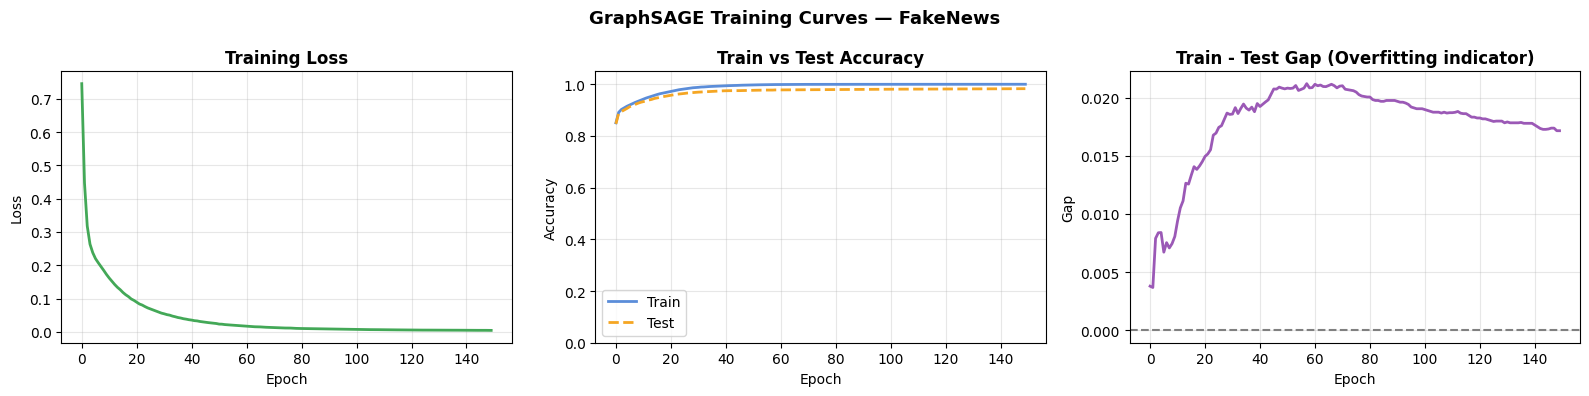

In [9]:
# ── Visualisation: Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(range(EPOCHS), train_losses, color='#43A857', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(EPOCHS), train_accs, color='#5B8DD9', linewidth=2, label='Train')
axes[1].plot(range(EPOCHS), test_accs,  color='#F5A623', linewidth=2, linestyle='--', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Test Accuracy', fontweight='bold')
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].grid(True, alpha=0.3)

gap = [tr - te for tr, te in zip(train_accs, test_accs)]
axes[2].plot(range(EPOCHS), gap, color='#9B59B6', linewidth=2)
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Gap')
axes[2].set_title('Train - Test Gap (Overfitting indicator)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('GraphSAGE Training Curves — FakeNews', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 Step 5 — Evaluation & So sánh GCN / GAT / GraphSAGE (FakeNews)

In [10]:
print("=" * 60)
print("STEP 5: GraphSAGE Evaluation on FakeNews Test Set")
print("=" * 60)

model_sage.eval()
with torch.no_grad():
    out_final  = model_sage(pyg_data)
    pred_test  = out_final[pyg_data.test_mask].argmax(dim=1).cpu().numpy()
    y_test     = pyg_data.y[pyg_data.test_mask].cpu().numpy()
    sage_fn_acc = accuracy_score(y_test, pred_test)

print(f"\n  ✅ GraphSAGE Test Accuracy on FakeNews : {sage_fn_acc:.4f} ({sage_fn_acc*100:.2f}%)\n")
print(classification_report(y_test, pred_test, target_names=['Real (0)', 'Fake (1)']))

STEP 5: GraphSAGE Evaluation on FakeNews Test Set

  ✅ GraphSAGE Test Accuracy on FakeNews : 0.9829 (98.29%)

              precision    recall  f1-score   support

    Real (0)       0.98      0.98      0.98      6379
    Fake (1)       0.98      0.99      0.98      7091

    accuracy                           0.98     13470
   macro avg       0.98      0.98      0.98     13470
weighted avg       0.98      0.98      0.98     13470



  GCN       Test Accuracy on FakeNews : 95.40%
  GAT       Test Accuracy on FakeNews : 92.29%
  GraphSAGE Test Accuracy on FakeNews : 98.29%


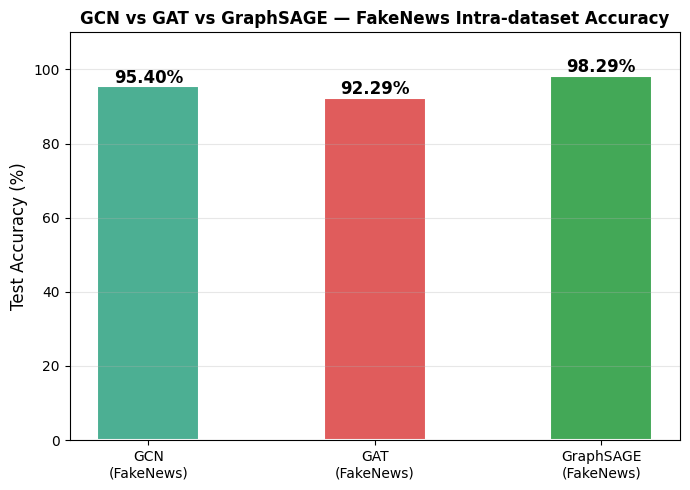

In [11]:
# ── So sánh GCN / GAT / GraphSAGE trên cùng FakeNews test split ──────────────
gcn_fn_acc = None
gat_fn_acc = None
model_gcn  = None
model_gat  = None

if CHECKPOINT_GCN.exists():
    ckpt_gcn  = torch.load(CHECKPOINT_GCN, map_location='cpu', weights_only=False)
    model_gcn = GCNModel(in_channels=ckpt_gcn['in_channels']).to(DEVICE)
    model_gcn.load_state_dict(ckpt_gcn['model_state_dict'])
    model_gcn.eval()

    with torch.no_grad():
        pred_gcn   = model_gcn(pyg_data)[pyg_data.test_mask].argmax(dim=1).cpu().numpy()
        gcn_fn_acc = accuracy_score(y_test, pred_gcn)

    print(f"  GCN       Test Accuracy on FakeNews : {gcn_fn_acc*100:.2f}%")
else:
    print("  ⚠️  gcn_fakenews.pt not found — run train_fakenews.ipynb for GCN comparison.")

if CHECKPOINT_GAT.exists():
    ckpt_gat  = torch.load(CHECKPOINT_GAT, map_location='cpu', weights_only=False)
    model_gat = GATModel(
        in_channels=ckpt_gat['in_channels'],
        hidden_channels=ckpt_gat.get('hidden_channels', 64),
        out_channels=2,
        heads=ckpt_gat.get('heads', 4),
        dropout=ckpt_gat.get('dropout', 0.5)
    ).to(DEVICE)
    model_gat.load_state_dict(ckpt_gat['model_state_dict'])
    model_gat.eval()

    with torch.no_grad():
        pred_gat   = model_gat(pyg_data)[pyg_data.test_mask].argmax(dim=1).cpu().numpy()
        gat_fn_acc = accuracy_score(y_test, pred_gat)

    print(f"  GAT       Test Accuracy on FakeNews : {gat_fn_acc*100:.2f}%")
else:
    print("  ⚠️  gat_fakenews.pt not found — run train_fakenews_gat.ipynb for GAT comparison.")

print(f"  GraphSAGE Test Accuracy on FakeNews : {sage_fn_acc*100:.2f}%")

# ── Bar chart ─────────────────────────────────────────────────────────────────
models     = []
accuracies = []
bar_colors = []

if gcn_fn_acc is not None:
    models.append('GCN\n(FakeNews)'); accuracies.append(gcn_fn_acc * 100); bar_colors.append('#4CAF93')
if gat_fn_acc is not None:
    models.append('GAT\n(FakeNews)'); accuracies.append(gat_fn_acc * 100); bar_colors.append('#E05C5C')
models.append('GraphSAGE\n(FakeNews)'); accuracies.append(sage_fn_acc * 100); bar_colors.append('#43A857')

fig, ax = plt.subplots(figsize=(max(5, len(models)*2+1), 5))
bars = ax.bar(models, accuracies, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.45)
ax.set_ylim(0, 110)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('GCN vs GAT vs GraphSAGE — FakeNews Intra-dataset Accuracy', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

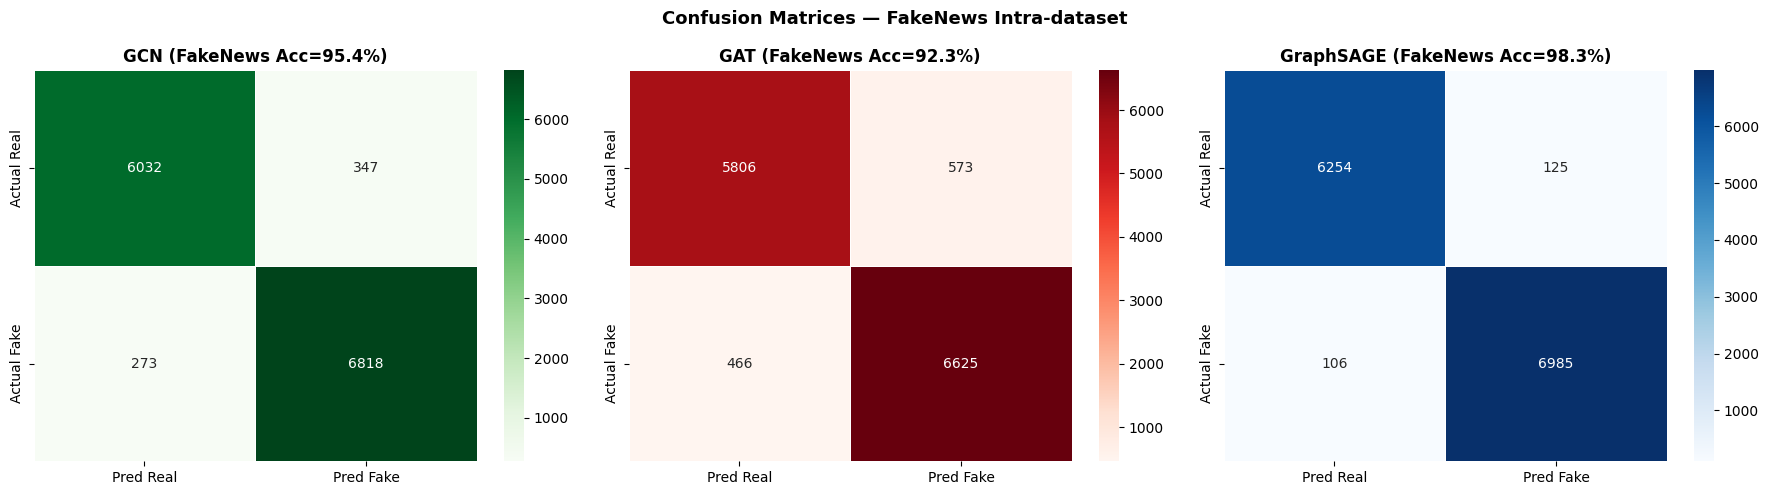

In [12]:
# ── Confusion matrix: GraphSAGE ───────────────────────────────────────────────
n_comp = 1 + (1 if gcn_fn_acc is not None else 0) + (1 if gat_fn_acc is not None else 0)
fig, axes = plt.subplots(1, n_comp, figsize=(6 * n_comp, 5))
if n_comp == 1:
    axes = [axes]

ax_idx = 0
if gcn_fn_acc is not None:
    cm_gcn = confusion_matrix(y_test, pred_gcn)
    sns.heatmap(cm_gcn, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Pred Real', 'Pred Fake'],
                yticklabels=['Actual Real', 'Actual Fake'],
                ax=axes[ax_idx], linewidths=0.5, linecolor='white')
    axes[ax_idx].set_title(f'GCN (FakeNews Acc={gcn_fn_acc*100:.1f}%)', fontweight='bold')
    ax_idx += 1

if gat_fn_acc is not None:
    cm_gat = confusion_matrix(y_test, pred_gat)
    sns.heatmap(cm_gat, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Pred Real', 'Pred Fake'],
                yticklabels=['Actual Real', 'Actual Fake'],
                ax=axes[ax_idx], linewidths=0.5, linecolor='white')
    axes[ax_idx].set_title(f'GAT (FakeNews Acc={gat_fn_acc*100:.1f}%)', fontweight='bold')
    ax_idx += 1

cm_sage = confusion_matrix(y_test, pred_test)
sns.heatmap(cm_sage, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['Actual Real', 'Actual Fake'],
            ax=axes[ax_idx], linewidths=0.5, linecolor='white')
axes[ax_idx].set_title(f'GraphSAGE (FakeNews Acc={sage_fn_acc*100:.1f}%)', fontweight='bold')

plt.suptitle('Confusion Matrices — FakeNews Intra-dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💾 Step 6 — Save GraphSAGE Checkpoint

In [13]:
checkpoint_sage = {
    'model_state_dict' : model_sage.state_dict(),
    'in_channels'      : MAX_FEATURES,
    'hidden_channels'  : SAGE_HIDDEN,
    'out_channels'     : 2,
    'dropout'          : SAGE_DROPOUT,
    'test_accuracy'    : float(sage_fn_acc),
    'timestamp'        : datetime.now().isoformat(),
    'hyperparams': {
        'sample_size'  : SAMPLE_SIZE,
        'max_features' : MAX_FEATURES,
        'knn_k'        : KNN_K,
        'epochs'       : EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay' : WEIGHT_DECAY,
    }
}

torch.save(checkpoint_sage, CHECKPOINT_SAGE)
print(f"  ✓ Saved : {CHECKPOINT_SAGE}")
print(f"  ✓ Size  : {CHECKPOINT_SAGE.stat().st_size/1024:.1f} KB")
print(f"  ✓ Acc   : {sage_fn_acc*100:.2f}% on FakeNews test set")

  ✓ Saved : /Users/macbook/Documents/HK2_Nam3(2526)/Theory/Graph Mining/Fake-News-Detection-GNN/output/checkpoints/sage_fakenews.pt
  ✓ Size  : 4008.5 KB
  ✓ Acc   : 98.29% on FakeNews test set


---
## 🌐 Step 7 — Cross-dataset Prediction on WelFake

Đánh giá GCN, GAT và GraphSAGE trên WelFake để có bảng so sánh **3 model × 2 dataset** đầy đủ.

In [14]:
sage_wf_acc = None
gcn_wf_acc  = None
gat_wf_acc  = None

if not WELFAKE_PATH.exists():
    print(f"⚠️  WELFake_Dataset.csv not found in {RAW_DIR}")
    print("   Download from: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification")
else:
    print("=" * 60)
    print("STEP 7: Cross-dataset Prediction on WelFake")
    print("=" * 60)

    # Load & preprocess WelFake
    df_wf = pd.read_csv(WELFAKE_PATH)
    df_wf['text']    = df_wf['text'].astype(str).apply(preprocess_text)
    df_wf['title']   = df_wf['title'].astype(str).apply(preprocess_text)
    df_wf['content'] = df_wf['title'] + " " + df_wf['text']
    df_wf_s = df_wf.sample(n=min(WELFAKE_SAMPLE, len(df_wf)), random_state=RANDOM_SEED).reset_index(drop=True)
    y_wf    = df_wf_s['label'].values
    print(f"  ✓ WelFake loaded : {len(df_wf_s):,} samples")

    # TF-IDF + KNN on WelFake (fit lại độc lập)
    X_wf = StandardScaler().fit_transform(
        TfidfVectorizer(max_features=MAX_FEATURES).fit_transform(df_wf_s['content']).toarray()
    )
    nbrs_wf   = NearestNeighbors(n_neighbors=KNN_K + 1, metric='cosine').fit(X_wf)
    _, idx_wf = nbrs_wf.kneighbors(X_wf)
    rw, cw = [], []
    for i in range(X_wf.shape[0]):
        for j in range(1, KNN_K + 1):
            rw.append(i); cw.append(idx_wf[i][j])
    adj_wf = csr_matrix((np.ones(len(rw)), (rw, cw)), shape=(X_wf.shape[0], X_wf.shape[0]))
    adj_wf = adj_wf.maximum(adj_wf.transpose()).tocoo()
    ei_wf  = torch.tensor(np.array([adj_wf.row, adj_wf.col]), dtype=torch.long)

    data_wf = Data(
        x=torch.tensor(X_wf, dtype=torch.float32).to(DEVICE),
        edge_index=ei_wf.to(DEVICE),
        y=torch.tensor(y_wf, dtype=torch.long).to(DEVICE)
    )

    # GCN prediction
    if model_gcn is not None:
        model_gcn.eval()
        with torch.no_grad():
            pred_gcn_wf = model_gcn(data_wf).argmax(dim=1).cpu().numpy()
            gcn_wf_acc  = accuracy_score(y_wf, pred_gcn_wf)
        print(f"  ✅ GCN       cross-dataset on WelFake : {gcn_wf_acc*100:.2f}%")
    else:
        print("  ℹ️  GCN checkpoint not available — GCN WelFake result skipped.")

    # GAT prediction
    if model_gat is not None:
        model_gat.eval()
        with torch.no_grad():
            pred_gat_wf = model_gat(data_wf).argmax(dim=1).cpu().numpy()
            gat_wf_acc  = accuracy_score(y_wf, pred_gat_wf)
        print(f"  ✅ GAT       cross-dataset on WelFake : {gat_wf_acc*100:.2f}%")
    else:
        print("  ℹ️  GAT checkpoint not available — GAT WelFake result skipped.")

    # GraphSAGE prediction
    model_sage.eval()
    with torch.no_grad():
        pred_sage_wf = model_sage(data_wf).argmax(dim=1).cpu().numpy()
        sage_wf_acc  = accuracy_score(y_wf, pred_sage_wf)
    print(f"  ✅ GraphSAGE cross-dataset on WelFake : {sage_wf_acc*100:.2f}%")

STEP 7: Cross-dataset Prediction on WelFake
  ✓ WelFake loaded : 3,000 samples
  ✅ GCN       cross-dataset on WelFake : 57.77%
  ✅ GAT       cross-dataset on WelFake : 60.43%
  ✅ GraphSAGE cross-dataset on WelFake : 58.60%


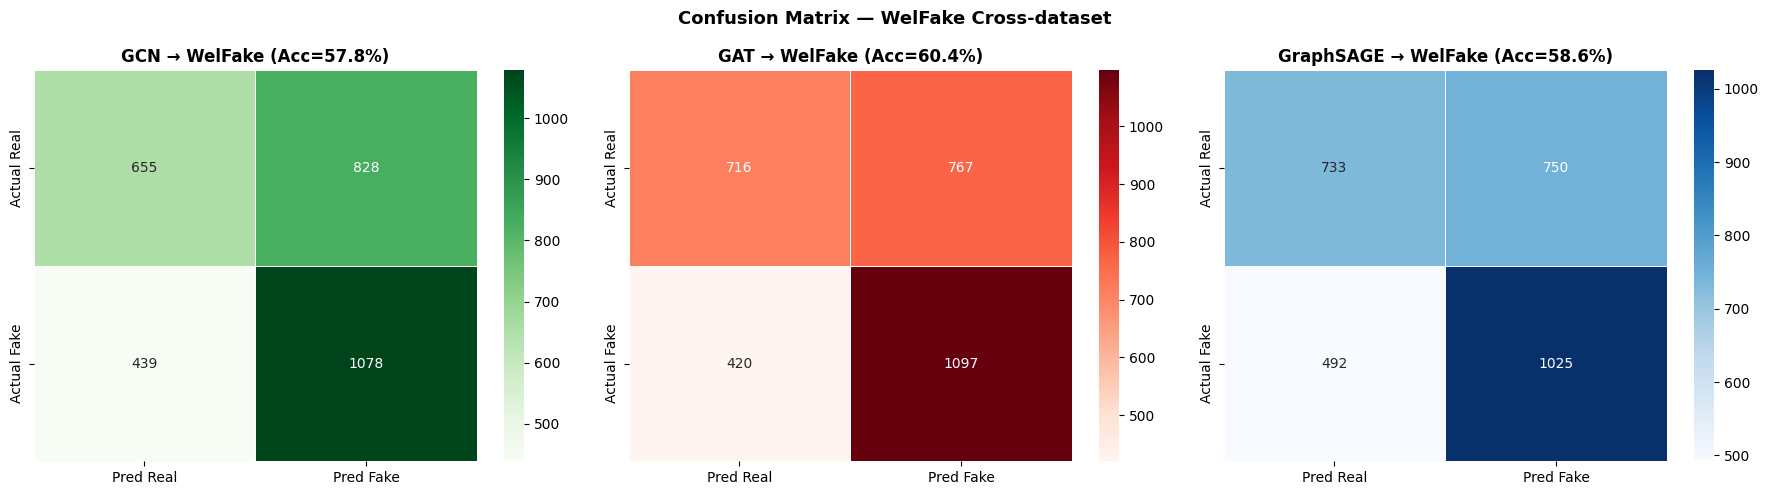

In [15]:
# ── Confusion matrices: WelFake cross-dataset ─────────────────────────────────
if sage_wf_acc is not None:
    avail = [('GCN', gcn_wf_acc, 'Greens'), ('GAT', gat_wf_acc, 'Reds'), ('GraphSAGE', sage_wf_acc, 'Blues')]
    avail = [(n, a, c) for n, a, c in avail if a is not None]
    ncols = len(avail)

    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
    if ncols == 1:
        axes = [axes]

    preds_wf = {'GCN': pred_gcn_wf if gcn_wf_acc else None,
                'GAT': pred_gat_wf if gat_wf_acc else None,
                'GraphSAGE': pred_sage_wf}

    for ax, (name, acc, cmap) in zip(axes, avail):
        cm = confusion_matrix(y_wf, preds_wf[name])
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                    xticklabels=['Pred Real', 'Pred Fake'],
                    yticklabels=['Actual Real', 'Actual Fake'],
                    ax=ax, linewidths=0.5, linecolor='white')
        ax.set_title(f'{name} → WelFake (Acc={acc*100:.1f}%)', fontweight='bold')

    plt.suptitle('Confusion Matrix — WelFake Cross-dataset', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("WelFake not available — skip confusion matrix.")

---
## 📋 Step 8 — Bảng So sánh Đầy đủ: GCN vs GAT vs GraphSAGE × FakeNews vs WelFake

In [16]:
print("=" * 60)
print("STEP 8: Comparison Table")
print("=" * 60)

# Build comparison data
rows_data = []
if gcn_fn_acc is not None:
    rows_data.append({'Model': 'GCN', 'FakeNews (intra)': f"{gcn_fn_acc*100:.2f}%",
                      'WelFake (cross)': f"{gcn_wf_acc*100:.2f}%" if gcn_wf_acc else 'N/A',
                      'Drop': f"{(gcn_fn_acc - gcn_wf_acc)*100:.2f}%" if gcn_wf_acc else 'N/A'})
if gat_fn_acc is not None:
    rows_data.append({'Model': 'GAT', 'FakeNews (intra)': f"{gat_fn_acc*100:.2f}%",
                      'WelFake (cross)': f"{gat_wf_acc*100:.2f}%" if gat_wf_acc else 'N/A',
                      'Drop': f"{(gat_fn_acc - gat_wf_acc)*100:.2f}%" if gat_wf_acc else 'N/A'})
rows_data.append({'Model': 'GraphSAGE', 'FakeNews (intra)': f"{sage_fn_acc*100:.2f}%",
                  'WelFake (cross)': f"{sage_wf_acc*100:.2f}%" if sage_wf_acc else 'N/A',
                  'Drop': f"{(sage_fn_acc - sage_wf_acc)*100:.2f}%" if sage_wf_acc else 'N/A'})

df_comp = pd.DataFrame(rows_data).set_index('Model')
print(df_comp.to_string())
print()
print("Drop = intra - cross (domain shift penalty)")

STEP 8: Comparison Table
          FakeNews (intra) WelFake (cross)    Drop
Model                                             
GCN                 95.40%          57.77%  37.63%
GAT                 92.29%          60.43%  31.85%
GraphSAGE           98.29%          58.60%  39.69%

Drop = intra - cross (domain shift penalty)


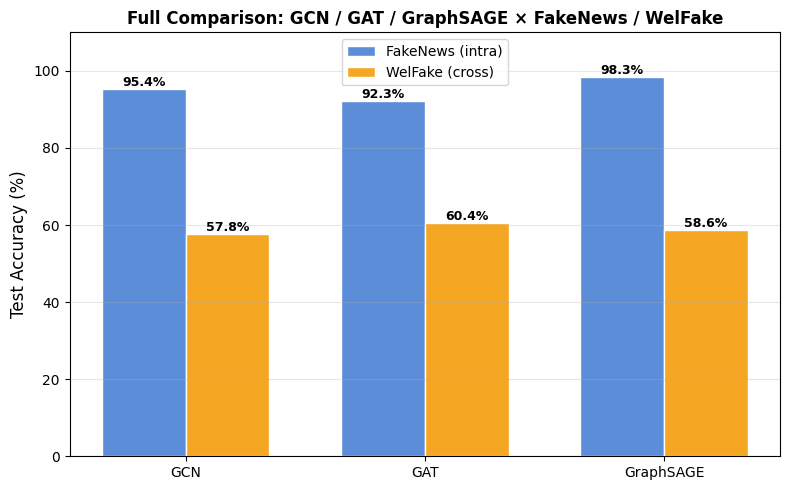

In [17]:
# ── Grouped bar chart: full 3×2 comparison ────────────────────────────────────
if sage_wf_acc is not None:
    model_names  = [r['Model'] for r in rows_data]
    intra_scores = [float(r['FakeNews (intra)'].strip('%')) for r in rows_data]
    cross_scores = [float(r['WelFake (cross)'].strip('%')) if r['WelFake (cross)'] != 'N/A' else 0 for r in rows_data]

    x   = np.arange(len(model_names))
    w   = 0.35
    fig, ax = plt.subplots(figsize=(max(7, len(model_names)*2+2), 5))

    b1 = ax.bar(x - w/2, intra_scores, width=w, label='FakeNews (intra)', color='#5B8DD9', edgecolor='white')
    b2 = ax.bar(x + w/2, cross_scores, width=w, label='WelFake (cross)',  color='#F5A623', edgecolor='white')

    ax.set_ylim(0, 110)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('Full Comparison: GCN / GAT / GraphSAGE × FakeNews / WelFake',
                 fontweight='bold', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    for bar in [*b1, *b2]:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                    f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("WelFake not available — skipping full comparison chart.")

---
## 📝 Ghi chú — GraphSAGE vs GAT vs GCN

| Khía cạnh | GCN | GAT | GraphSAGE |
|---|---|---|---|
| **Cơ chế** | Spectral convolution | Attention-weighted agg. | Sample + Mean/Max agg. |
| **Inductive** | ❌ | Một phần | ✅ Fully inductive |
| **Tham số** | Ít nhất | Nhiều nhất | Trung bình |
| **Tốc độ** | Nhanh | Chậm | Nhanh (mini-batch) |
| **Interpretability** | Thấp | Cao (attention weights) | Trung bình |
| **Phù hợp** | Small static graph | Dynamic importance | Large inductive graph |

**GraphSAGE** đặc biệt phù hợp khi:
- Cần học biểu diễn cho node **chưa thấy** (inductive learning)
- Graph quá lớn, cần **mini-batch sampling**
- Không cần giải thích tại sao node nào quan trọng (không cần attention)

Trong bài toán phát hiện tin giả, GraphSAGE có thể tổng quát hóa tốt hơn
qua các dataset khác nhau nhờ khả năng **inductive learning** mạnh hơn.
